# Goal

* What convolution means for 1D, 2D, and 3D signals
* How to interpret the results of convolution
* Why convolution is so powerful and important in machine-learning (feature-extraction and pattern-matching)

# Theoretical Minimum

## Dot Product 1D

In [18]:
import numpy as np

a = [1,0,2,5,-2]
b = [2,8,-6,1,0]
a, b

([1, 0, 2, 5, -2], [2, 8, -6, 1, 0])

$$ v^T w = 1\times 2 + 0 \times 8 + 2 \times (-6) + 5 \times 1 + (-2)\times 0 = -5$$

In [26]:
dot = 0
for i in range(len(a)):
  print(f'{a[i]} + {b[i]}')
  dot += a[i] * b[i]

1 + 2
0 + 8
2 + -6
5 + 1
-2 + 0


In [27]:
dot

-5

In [28]:
np.dot(a,b)

np.int64(-5)

## Dot Product 2D

In [33]:
a = [
    [0,3,2],
    [-3,-3,1],
    [1,0,2]
]

b = [
    [1,0,6],
    [2,-1,0],
    [5,1,4]
]

In [34]:
a

[[0, 3, 2], [-3, -3, 1], [1, 0, 2]]

In [35]:
b

[[1, 0, 6], [2, -1, 0], [5, 1, 4]]

In [42]:
dot = 0
for i in range(len(a)):
  for j in range(len(a[0])):
    print(f'{a[i][j]} * {b[i][j]}')
    dot += a[i][j] * b[i][j]

0 * 1
3 * 0
2 * 6
-3 * 2
-3 * -1
1 * 0
1 * 5
0 * 1
2 * 4


In [44]:
dot

22

 ## Convolution 1D

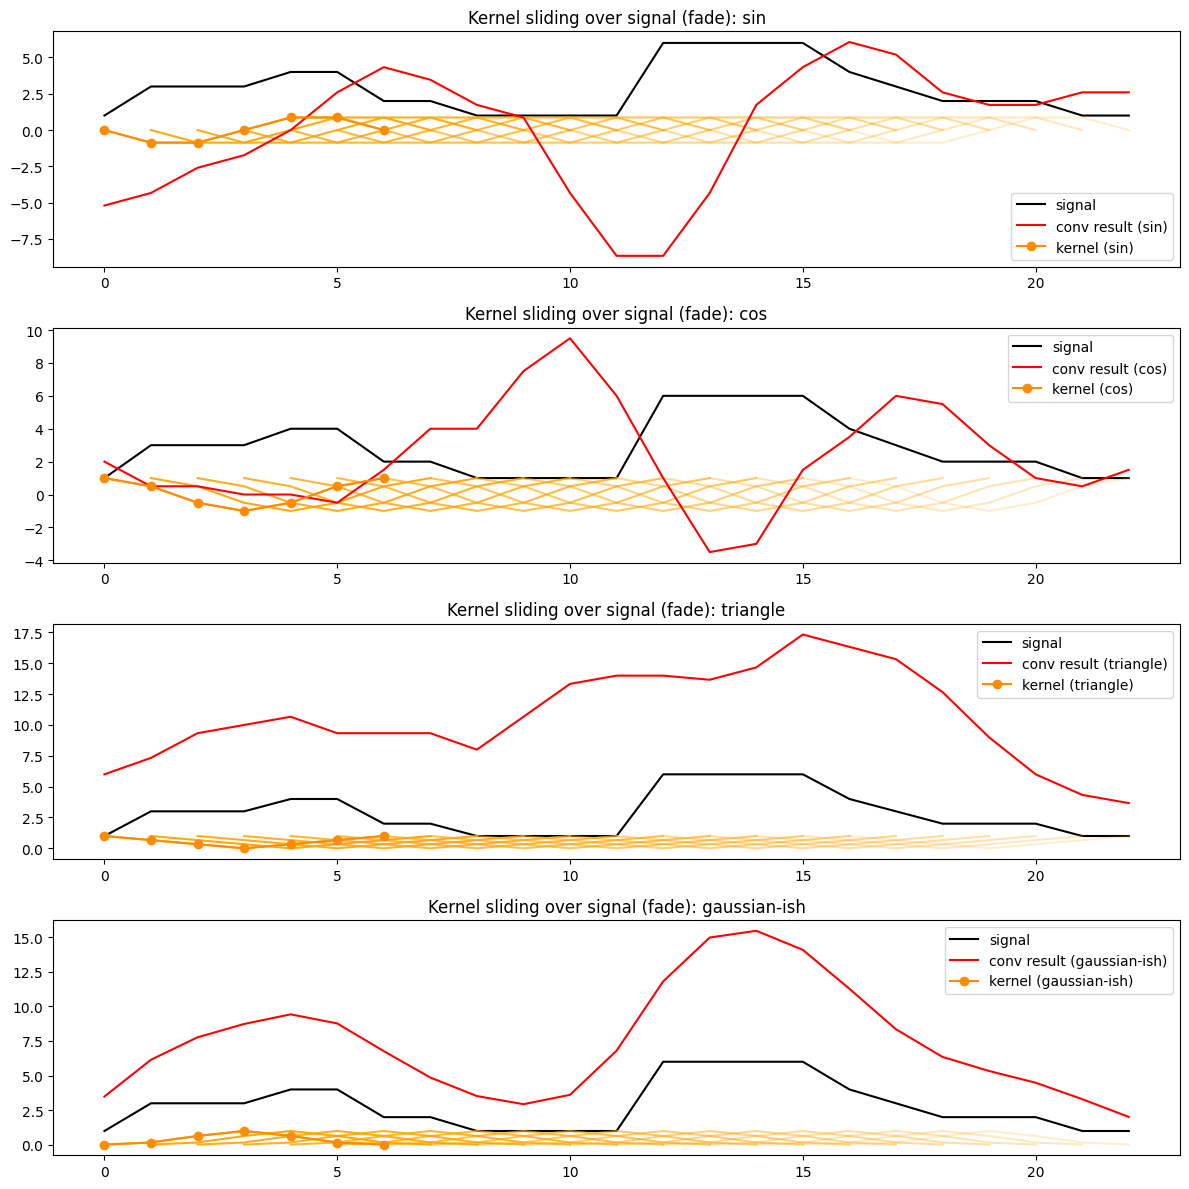

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# sygnał
signal = np.array([1,3,3,3,4,4,2,2,1,1,1,1,6,6,6,6,4,3,2,2,2,1,1])
N = len(signal)

# --- KERNELE ---
kernel_size = 7
x = np.linspace(0, 2*np.pi, kernel_size)

kernels = {
    "sin": np.sin(x),
    "cos": np.cos(x),
    "triangle": np.abs(np.linspace(-1, 1, kernel_size)),
    "gaussian-ish": np.exp(-((np.linspace(-1, 1, kernel_size))**2) * 4)
}

# odwrócenie (klasyczna konwolucja)
for k in kernels:
    kernels[k] = kernels[k][::-1]

plt.figure(figsize=(12, 12))

for i, (name, kernel) in enumerate(kernels.items()):
    result = np.convolve(signal, kernel, mode='same')

    plt.subplot(4, 1, i+1)
    plt.plot(signal, label="signal", color="black")

    # --- SLIDING KERNELS W FADE-OUT ---
    shifts = N - kernel_size + 1

    for shift in range(shifts):
        alpha = 1 - (shift / shifts) * 0.85  # fade from 1 → 0.15
        plt.plot(
            np.arange(shift, shift + kernel_size),
            kernel,
            color="orange",
            alpha=alpha
        )

    # wynik konwolucji
    plt.plot(result, label=f"conv result ({name})", color="red")

    # kernel na pozycji 0 (wyraźny)
    plt.plot(np.arange(kernel_size), kernel, label=f"kernel ({name})",
             color="darkorange", marker='o')

    plt.title(f"Kernel sliding over signal (fade): {name}")
    plt.legend()

plt.tight_layout()
plt.show()

## Convolution 2D

# Convolution

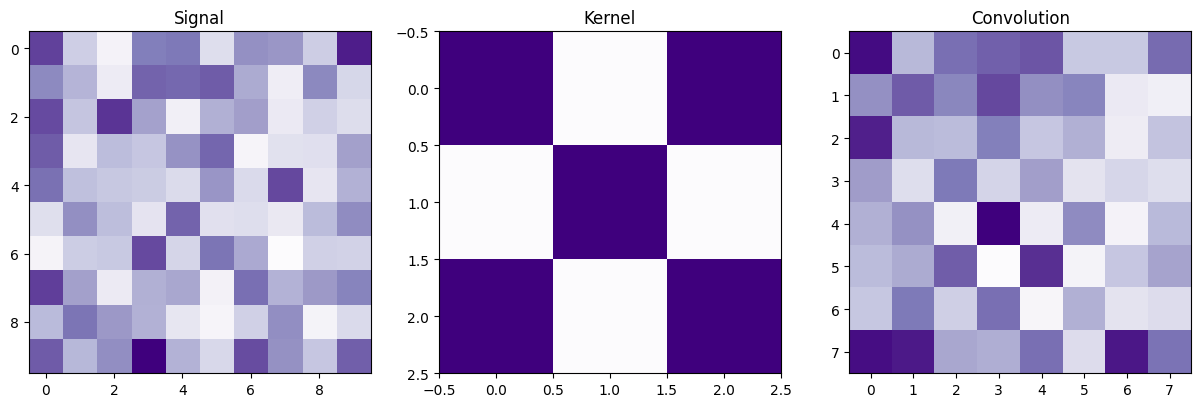



Shape of Signal: (10, 10)
Shape of Kernel: (3, 3)
Shape of Convolution: (8, 8)


In [154]:
import numpy as np
from scipy.signal import convolve2d

fig, ax = plt.subplots(1,3,figsize = (15,5))

signal = np.random.randn(10,10)
kernel = np.array([[1, 0,   1],
                   [0,   1, 0],
                   [1, 0,   1]])
ax[0].imshow(signal, cmap = 'Purples')
ax[0].set_title('Signal')

ax[1].imshow(kernel, cmap = 'Purples')
ax[1].set_title('Kernel')

result = convolve2d(signal, kernel, mode = 'valid')
ax[2].imshow(result, cmap = 'Purples')
ax[2].set_title('Convolution')

plt.show()

print('\n')
print(f'Shape of Signal: {signal.shape}')
print(f'Shape of Kernel: {kernel.shape}')
print(f'Shape of Convolution: {result.shape}')

## Implementation

Kernel and Image

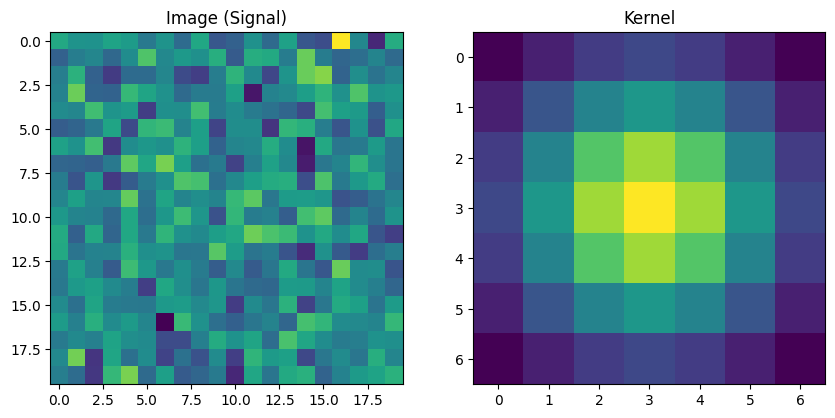

In [268]:
image_n = 20
image = np.random.randn(image_n, image_n)

kernel_n = 7
half_kernel_n = kernel_n // 2
X, Y = np.meshgrid(np.linspace(-half_kernel_n,
                               half_kernel_n,
                               kernel_n),
                   np.linspace(-half_kernel_n,
                               half_kernel_n,
                               kernel_n))
kernel = np.exp(-(X**2 + Y**2)/kernel_n)


fig, ax = plt.subplots(1,2,figsize = (10,10))

ax[0].imshow(image)
ax[0].set_title('Image (Signal)')

ax[1].imshow(kernel)
ax[1].set_title('Kernel')

plt.show()

Implemented Convolution

In [276]:
conv_output_manual = np.zeros((image_n, image_n))

for row_i in range(half_kernel_n, image_n - half_kernel_n):
  for col_i in range(half_kernel_n, image_n - half_kernel_n):

    image_piece = image[row_i - half_kernel_n : row_i + half_kernel_n + 1, :]
    image_piece = image_piece[:, col_i - half_kernel_n : col_i + half_kernel_n + 1]

    dot_prod = np.sum(image_piece * kernel[::-1, ::-1])

    conv_output_manual[row_i, col_i] = dot_prod

Convolution with SciPy

In [283]:
conv_output_scipy = convolve2d(image, kernel, mode = 'valid')

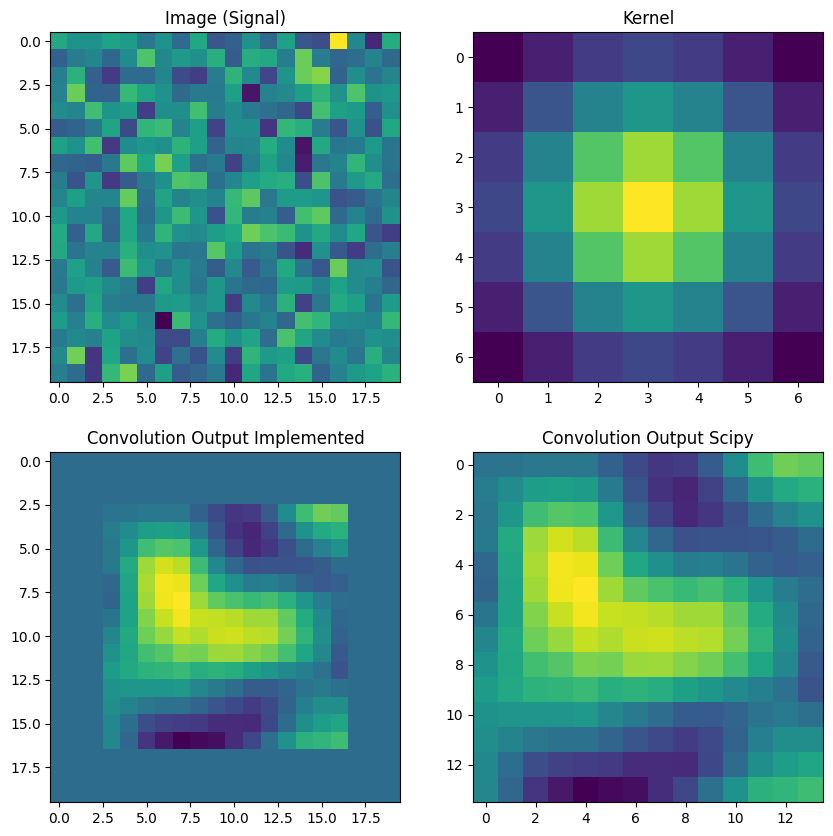

In [287]:
fig, ax = plt.subplots(2,2,figsize = (10,10))

ax[0][0].imshow(image)
ax[0][0].set_title('Image (Signal)')

ax[0][1].imshow(kernel)
ax[0][1].set_title('Kernel')

ax[1][0].imshow(conv_output_manual)
ax[1][0].set_title('Convolution Output Implemented')

ax[1][1].imshow(conv_output_scipy)
ax[1][1].set_title('Convolution Output Scipy')

plt.show()

## In SciPy

In [290]:
import imageio.v2 as imageio

url = "/content/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam (1).jpg"

bath_tub = imageio.imread(url)
bath_tub.shape

(1675, 3000, 3)

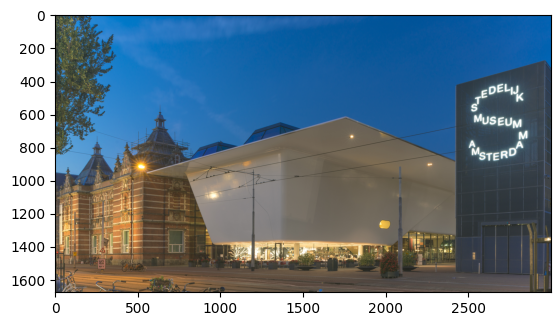

In [291]:
plt.imshow(bath_tub)
plt.show()

Let's make it 2D by averaging among 3rd dimension.

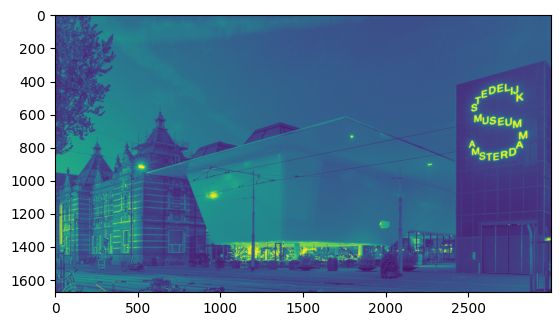

In [292]:
bath_tub = np.mean(bath_tub, axis = 2)
plt.imshow(bath_tub)
plt.show()

Let's now create vertical and horizontal kernels and create convolution from kernel and image.

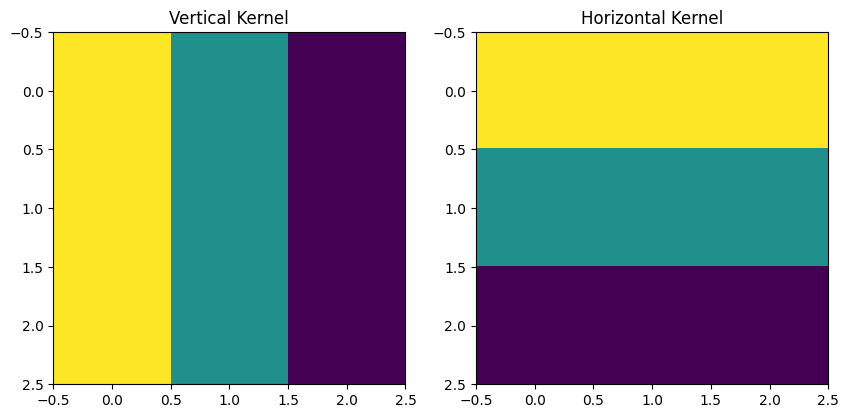

In [316]:
v_kernel = np.array([
    [1,0,-1],
    [1,0,-1],
    [1,0,-1]
])

h_kernel = np.array([
    [1,1,1],
    [0,0,0],
    [-1,-1,-1]
])

fig, ax = plt.subplots(1,2,figsize = (10,5))

ax[0].imshow(v_kernel)
ax[0].set_title('Vertical Kernel')
ax[1].imshow(h_kernel)
ax[1].set_title('Horizontal Kernel')

plt.show()

In [317]:
v_bath_tub = convolve2d(bath_tub, v_kernel, mode = 'same')
h_bath_tub = convolve2d(bath_tub, h_kernel)

fig, ax = plt.subplots(2,2,figsize = (20,10), gridspec_kw={'height_ratios': [1, 2]} )

ax[0][0].imshow(v_kernel)
ax[0][0].set_title('Vertical Kernel')
ax[0][1].imshow(h_kernel)
ax[0][1].set_title('Horizontal Kernel')

ax[1][0].imshow(v_bath_tub, cmap = 'grey', vmin = 0, vmax = 0.001, aspect = 'auto')
ax[1][0].set_title('Vertical Convolution')
ax[1][1].imshow(h_bath_tub, cmap = 'grey', vmin = 0, vmax = 0.001, aspect = 'auto')
ax[1][1].set_title('Horizontal Convolution')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

As we can see, vertical kernel returned convolution that is assembled from vertical lines, and horizontal returned convolution with horizontal ones.

## In PyTorch

We need to convert kernel and signal into tensors. Torch accepts tensors in conv2d in following shape:

$$ (\text{images_in_batch, channels, width, height}) $$

In [329]:
import torch
import torch.nn.functional as F

# torch accepts following shape: (images_in_batch, channels, width, height)
v_kernel_t = torch.tensor(v_kernel).view(1,1,v_kernel.shape[0], v_kernel.shape[1]).double()
h_kernel_t = torch.tensor(h_kernel).view(1,1,h_kernel.shape[0], h_kernel.shape[1]).double()
bath_tub_t = torch.tensor(bath_tub).view(1,1,bath_tub.shape[0], bath_tub.shape[1])
bath_tub.shape

(1675, 3000)

Now conv2d

In [328]:
conv_output = F.conv2d(bath_tub_t, v_kernel_t)
conv_output, conv_output.shape

(tensor([[[[-33.3333,  41.0000,  35.0000,  ...,   7.0000,  -9.0000,  -3.3333],
           [-38.0000,   8.0000,  73.0000,  ...,   5.3333,  -1.3333,  -5.3333],
           [ -8.0000,   7.3333,  58.3333,  ...,   7.0000,   1.3333,   0.3333],
           ...,
           [ 13.3333,   2.0000,  -6.6667,  ...,   0.3333,  -1.3333,   6.0000],
           [  9.0000,  -0.3333,   4.0000,  ...,   2.6667,   0.3333,   6.0000],
           [ -7.3333, -11.0000,  15.3333,  ...,   1.0000,   3.0000,   3.0000]]]],
        dtype=torch.float64),
 torch.Size([1, 1, 1673, 2998]))

We've lost 2 pixels in width and height. Nowe let's run conv2d with torch on vertical and horizontal kernels.

In [334]:
v_conv_output = F.conv2d(bath_tub_t, v_kernel_t)
h_conv_output = F.conv2d(bath_tub_t, h_kernel_t)
v_conv_output.shape, h_conv_output.shape

(torch.Size([1, 1, 1673, 2998]), torch.Size([1, 1, 1673, 2998]))

Before plotting we need to change plots from 4d into 2d.

In [336]:
v_conv_output = torch.squeeze(v_conv_output)
h_conv_output = torch.squeeze(h_conv_output)

v_conv_output.shape, h_conv_output.shape

(torch.Size([1673, 2998]), torch.Size([1673, 2998]))

In [337]:
fig, ax = plt.subplots(2,2,figsize = (20,10), gridspec_kw={'height_ratios': [1, 2]} )

ax[0][0].imshow(v_kernel)
ax[0][0].set_title('Vertical Kernel')
ax[0][1].imshow(h_kernel)
ax[0][1].set_title('Horizontal Kernel')

ax[1][0].imshow(v_conv_output, cmap = 'grey', vmin = 0, vmax = 0.001, aspect = 'auto')
ax[1][0].set_title('Vertical Convolution')
ax[1][1].imshow(h_conv_output, cmap = 'grey', vmin = 0, vmax = 0.001, aspect = 'auto')
ax[1][1].set_title('Horizontal Convolution')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Stride and Padding

* Two very important parameters of convolution
* How convolution can be used for downsampling
* The formulas for computing the size of the result of 2D convolution

$$ N_h = \Big\lfloor \frac{M_h + 2_p - k}{s_h} \Big\rfloor $$

* $ N_h - \text{Number of pixels in current layer} $
* $ M_h - \text{Number of pixels in previous layer} $
* $ p - \text{Padding} $
* $ k - \text{Number of pixels in kernel (height)} $
* $ s_h - \text{Stride} $
* $ \Big\lfloor...\Big\rfloor - \text{Floor} $

# PyTorch Conv2 class

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [5]:
in_channels = 3
out_channels = 15
kernel = 5
stride = 1
padding = 0

c = nn.Conv2d(in_channels,
              out_channels,
              kernel,
              stride,
              padding)

c

Conv2d(3, 15, kernel_size=(5, 5), stride=(1, 1))

In [7]:
print('Size of weights: ' + str(c.weight.shape))
print('Size of biases: ' + str(c.bias.shape))

Size of weights: torch.Size([15, 3, 5, 5])
Size of biases: torch.Size([15])


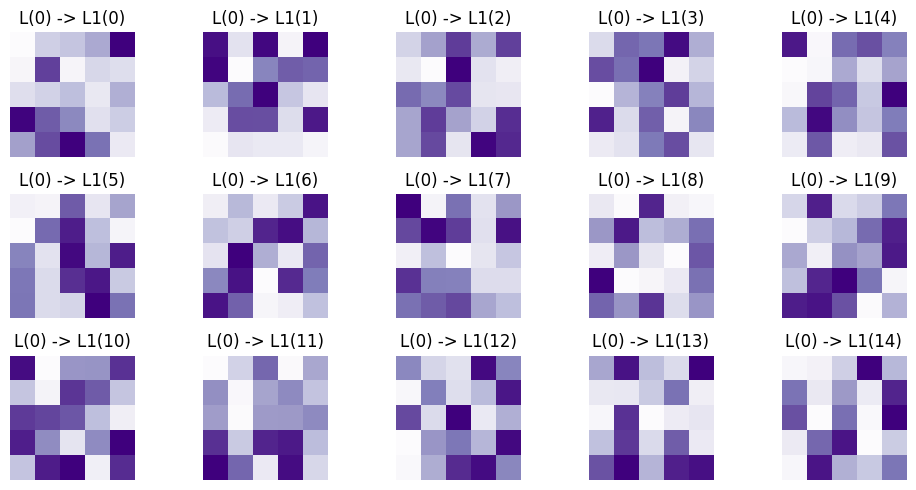

In [35]:
fig, axs = plt.subplots(3, 5, figsize = (10,5))

for i, ax in enumerate(axs.flatten()):
  ax.imshow(torch.squeeze(c.weight[i,0,:,:]).detach(), cmap = 'Purples')
  ax.set_title('L(0) -> L1(%s)'%i)
  ax.axis('off')

plt.tight_layout()
plt.show()

PyTorch wants channels first, matplotlib wants channels last

In [40]:
import numpy as np

imsize = (1,3,64,64)

img = torch.rand(imsize)

img_2_view = img.permute(2,3,1,0).numpy()

img.shape, img_2_view.shape

(torch.Size([1, 3, 64, 64]), (64, 64, 3, 1))

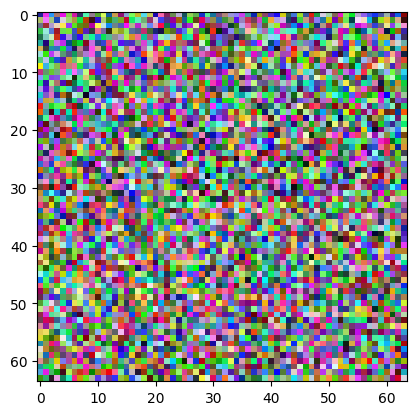

In [42]:
plt.imshow(np.squeeze(img_2_view))
plt.show()

In [44]:
conv_res = c(img)

img.shape, conv_res.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1, 15, 60, 60]))

We have in 3 channels and out 15 channels. Also due to lack of padding we have 4 pixels less in x and y axis.

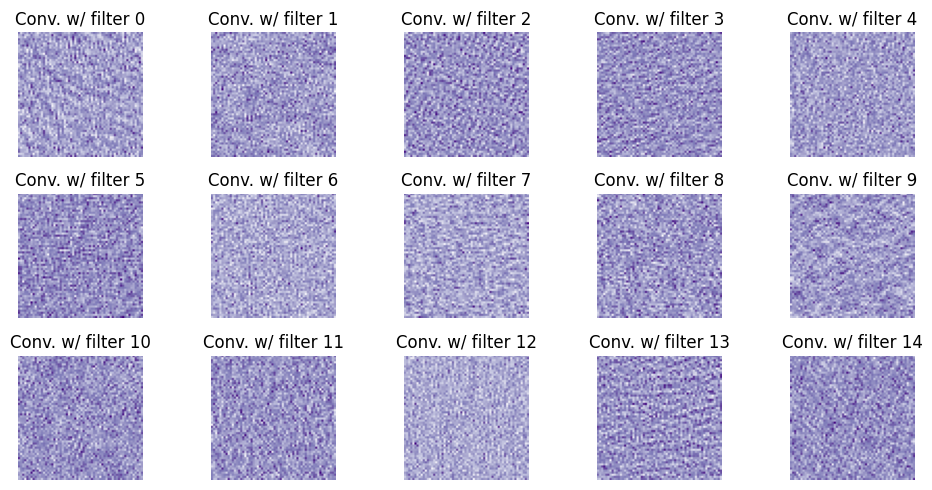

In [46]:
fig, axs = plt.subplots(3,5,figsize=(10,5))

for i, ax in enumerate(axs.flatten()):
  # extract this "layer" of the convolution result
  l = torch.squeeze(conv_res[0,i,:,:]).detach()

  # and visualize it
  ax.imshow(l, cmap = 'Purples')
  ax.set_title('Conv. w/ filter %s'%i)
  ax.axis('off')

plt.tight_layout()
plt.show()

# Transpose Convolution

## Goal

* What transpose convolution means and why it's important for autoencoders
* How transpose convolution is used for upsampling
* How to implement transpose convolution in PyTorch

## Intro

* Transpose convolution means to scalar-multiply a kernel by each pixel in an image (in other way around as in traditional convolution)
* As long as the kernel is >1 pixel, the result will be higher resolution than the original image
* Transpose convolution is used for autoencoders and super-resolution CNNs
* Transpose convolution takes the same parameters as forward convolution: kernel size, padding, stride

$$ N_h = s_h (M_h - 1) + k -2p $$

* $ N_h - \text{Number of pixels in current layer} $
* $ M_h - \text{Number of pixels in previous layer} $
* $ p - \text{Padding} $
* $ k - \text{Number of pixels in kernel (height)} $
* $ s_h - \text{Stride} $

## Code

In [29]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

### Create Transpose Convolution layer

In [15]:
in_channels = 3
out_channels = 15
kernel_size = 5
stride = 1
padding = 0

c = nn.ConvTranspose2d(in_channels,
                       out_channels,
                       kernel_size,
                       stride,
                       padding)

c

ConvTranspose2d(3, 15, kernel_size=(5, 5), stride=(1, 1))

In [16]:
print('Weight shape:',c.weight.shape)
print('Bias shape:',c.bias.shape)

Weight shape: torch.Size([3, 15, 5, 5])
Bias shape: torch.Size([15])


### Plot Kernel

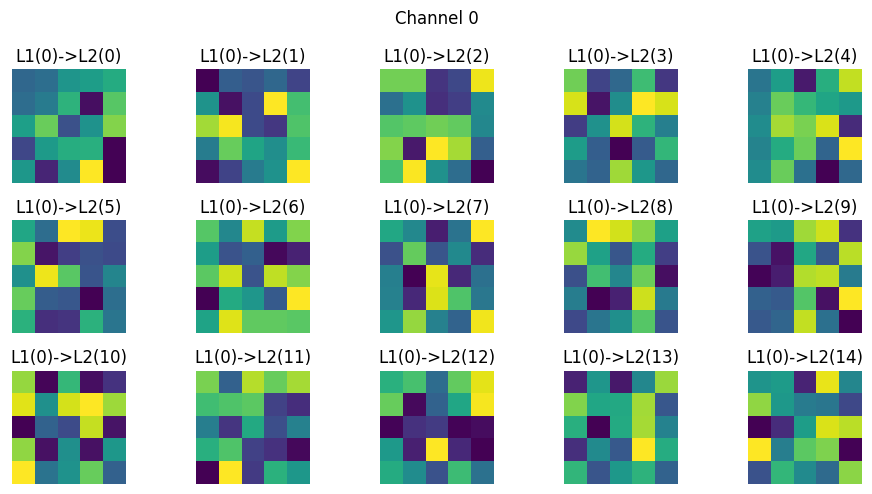

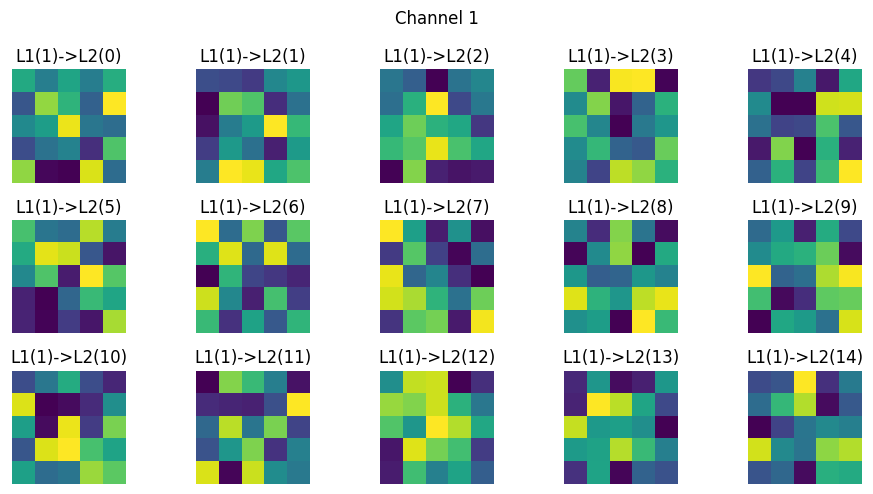

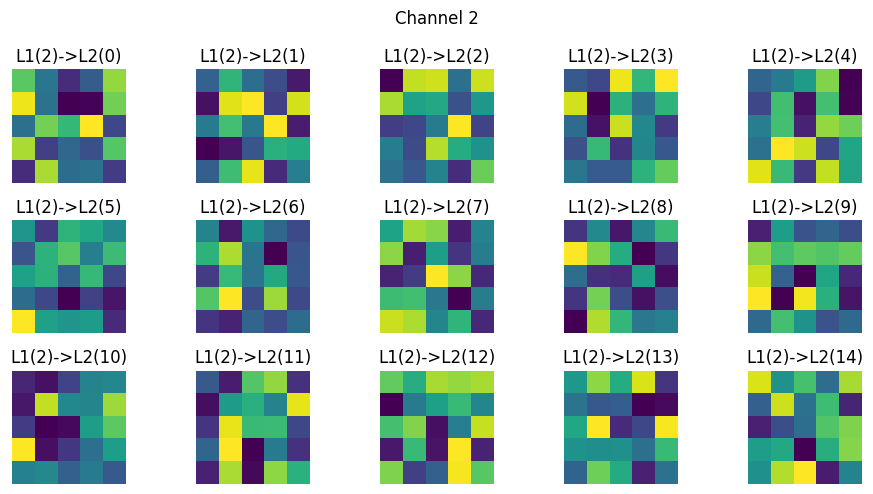

In [60]:
for ch in range(3):
  fig, axs = plt.subplots(3,5,figsize = (10,5))
  for i, ax in enumerate(axs.flatten()):
    ax.imshow(c.weight[ch,i,:,:].detach())
    ax.set_title(f'L1({ch})->L2({i})')
    ax.axis('off')
    fig.suptitle(f'Channel {ch}')
    plt.tight_layout()
plt.show()

### Create Image

Original Image Shape: torch.Size([1, 3, 64, 64])
Plotly Image Shape: (64, 64, 3, 1)



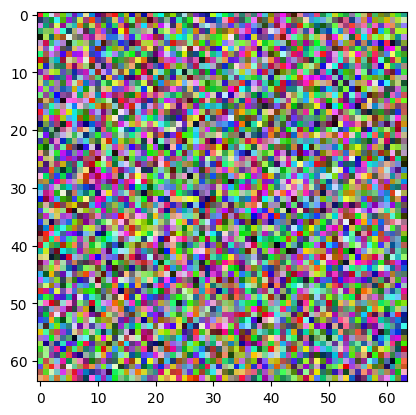

In [61]:
image_size = (1, 3, 64, 64) # (n, RGB, width, height)
image = torch.rand(image_size)
image_plt = image.permute(2,3,1,0).numpy()

print(f'Original Image Shape: {image.shape}')
print(f'Plotly Image Shape: {image_plt.shape}\n')

plt.imshow(image_plt.squeeze())
plt.show()

### Create Feature Map

In [68]:
feature_map = c(image)
print(f'Original Image Shape: {image.shape}')
print(f'Feature Map Shape: {feature_map.shape}')

Original Image Shape: torch.Size([1, 3, 64, 64])
Feature Map Shape: torch.Size([1, 15, 68, 68])


Since we're doing Transpose Convolution we're getting bigger output than input.

### Plot Feature Map

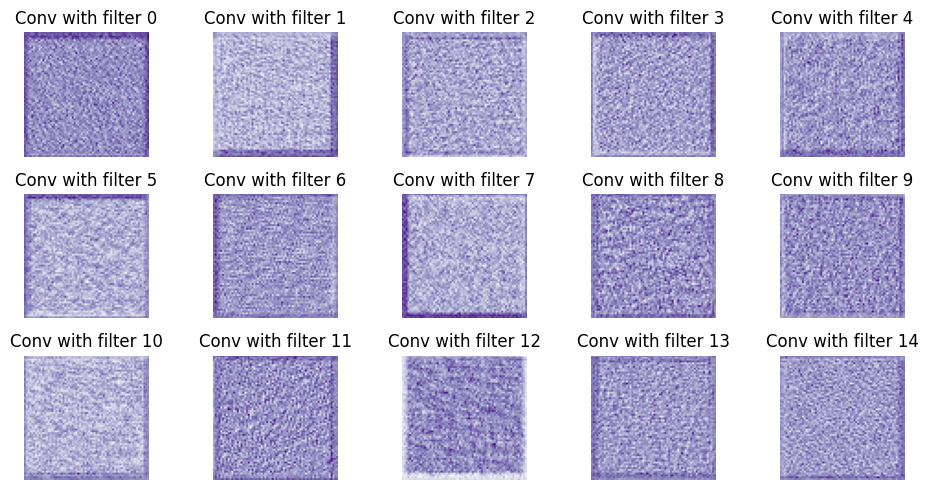

In [76]:
fig, axs = plt.subplots(3,5,figsize = (10,5))
for i, ax in enumerate(axs.flatten()):
  ax.imshow(feature_map[0,i,:,:].detach().squeeze(), cmap = 'Purples')
  ax.set_title(f'L1({ch})->L2({i})')
  ax.axis('off')
  ax.set_title('Conv with filter %s'%i)
  plt.tight_layout()
plt.show()

# Max/Mean Pooling

* What "pooling" means in CNN
* Why and where pooling is used
* The dimensionality of pooling

In average or max pooling, overlapping depends on the stride. If the stride equals the kernel size, pooling is non-overlapping and the output feature map is smaller than the input. Pooling is a method of downsampling.

## Why to use pooling?

* Reduces dimensionality (fewer params)
* Select for features over a broader spatial area (increased "receptive field" size)
* Deeper into the model, we want more channels with fewer pixels. This makes the representations increasingly abstract.

## Max or Mean?

* Max pooling: Highlights sharp features. Useful for sparse data and increasing contrast.
* Mean pooling: Smooths images (it's a low-passs filter). Useful for noisy data and to reduce the impact of outliers on learning.

## Receptive Fields

* ANNs have a one-to-one mapping between pixel and unit. In other words, the receptive field of an ANN units is one pixel.
* This makes the model non-robust to translations, resizing, rotations, etc.
* We want a model that can "see" the features anywhere in the image

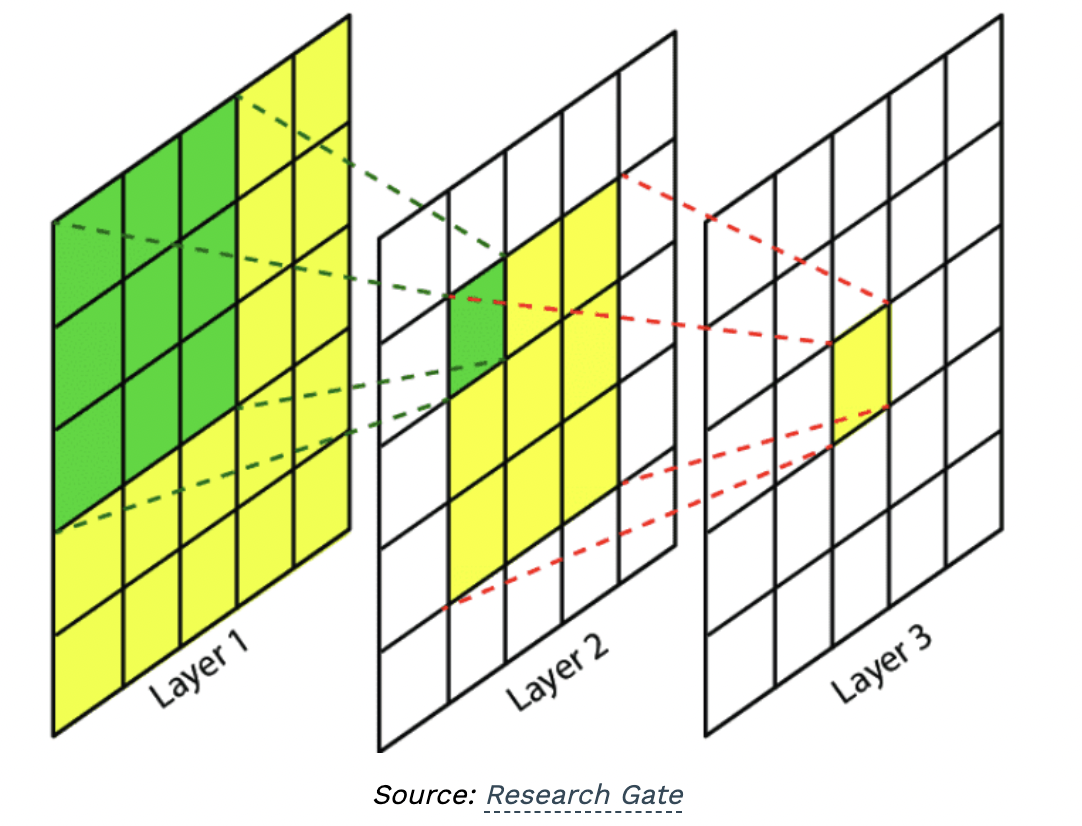

Receptive Field is simply an area of pixels ***on original image*** that is the basis of given cell from given layer. Layer 1 has the smallest receptive field because it's equal to the kernel size. Further layers' cells have more information (cells from original image) condensed in it. If neural net is deep enough we can find cells whichs' receptive field is equal to the whole original image, it's not necessary though - effective receptive field usually is smaller than the image, but of course never can be bigger than image size. There is also theoretical receptive field which includes paddings, ketnel, stride, dilation, pooling so it can be eventually bigger than original image.

### Parameters of Pooling

Spatial extent ("kernel size" but we already use kernel size elsewhere) is the number of pixels in the pooling window. Typically set to 2 (actually 2x2). If Stride is lower than Kernel then we have overlapping pooling.

Stride: The number of pixels to skip for each window. Typically set to 2 (produces no overlap).

### PyTorch

In [13]:
import torch
import torch.nn as nn

# create a pool class instance with parameters

# parameters
pool_size = 3
pool_stride = 3

# create the instace
p2 = nn.MaxPool2d(pool_size,pool_stride)
p3 = nn.MaxPool3d(pool_size, pool_stride)

p2, p3

(MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False),
 MaxPool3d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False))

In [14]:
# Create image and apply maxpooling

# create a 2D and a 3D image
img2 = torch.randn(1,1,30,30)
img3 = torch.randn(1,3,30,30)

# all combinations of image and maxpool dimensionality
img2_pool2 = p2(img2)
print(f'2D image, 2D maxpool: {img2_pool2.shape}\n')

# NOT EXISTS - WILL RETURN ERROR
# img2_pool3 = p3(img2)
# print(f'2D image, 3D maxpool: {img2_pool3.shape}\n')

img3_pool2 = p2(img3)
print(f'3D image, 2D maxpool: {img3_pool2.shape}\n')

img3_pool3 = p3(img3)
print(f'3D image, 3D maxpool: {img3_pool3.shape}')

2D image, 2D maxpool: torch.Size([1, 1, 10, 10])

3D image, 2D maxpool: torch.Size([1, 3, 10, 10])

3D image, 3D maxpool: torch.Size([1, 1, 10, 10])


# Simple CNN

## Test Net

In [17]:
little_net = nn.Sequential(
    # conv-pool block
    nn.Conv2d(in_channels = 3,
              out_channels = 10,
              kernel_size = 5,
              stride = 3,
              padding = 2),           # convolution layer
    nn.ReLU(),                        # activation function
    nn.AvgPool3d(kernel_size = 3,
                 stride = 3),         # average-pool


    # # the FFN block
    # nn.Flatten(),                     # vectorize to get from image to linear
    # nn.Linear(588,1),                 # FC linear layer
    # nn.Sigmoid()                      # output activation
    )

In [26]:
# test with a bit of data
img = torch.rand(4,3,128,128)
little_net(img).numel()

588

## Breakdown

### Conv Block

Let's create raw neural net with only CONVOLUTION BLOCK

In [41]:
import torch.nn

# image
in_channels = 3
out_channels = 1
kernel_size = 5
stride = 1
padding = 0

# pooling
pool_kernel_size = 3
pool_stride = 3


little_net = nn.Sequential(
    ### CONVOLUTION BLOCK ###
    nn.Conv2d(in_channels = in_channels,
              out_channels = out_channels,
              kernel_size = kernel_size,
              stride = stride,
              padding = padding),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size = pool_kernel_size,
                 stride = pool_stride)
)

little_net

Sequential(
  (0): Conv2d(3, 1, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): AvgPool2d(kernel_size=3, stride=3, padding=0)
)

### Test Image

Let's create testing image

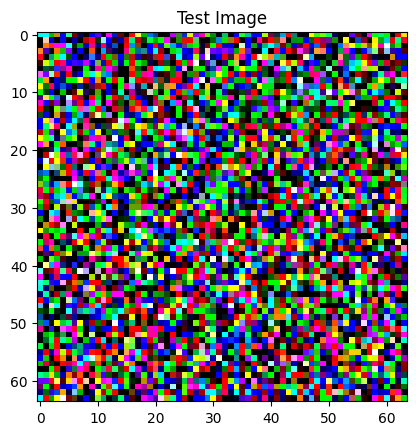

In [42]:
import matplotlib.pyplot as plt

img = torch.randn(1, 3, 64, 64)
plt.imshow(img.squeeze().permute(2,1,0))
plt.title('Test Image')
plt.show()

### Check numel()

Now let's check what size will have image after convolution block

In [44]:
little_net(img).numel()

400

or

In [45]:
len(little_net(img).flatten())

400

### FFN Block

So, now we know we need nn.Linear with 400 input nodes. Let's add FFN block to our little_net.

In [48]:
little_net = nn.Sequential(
    ### CONVOLUTION BLOCK ###
    nn.Conv2d(in_channels = in_channels,
              out_channels = out_channels,
              kernel_size = kernel_size,
              stride = stride,
              padding = padding),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size = pool_kernel_size,
                 stride = pool_stride),

    ### FFN BLOCK ###
    nn.Flatten(),
    nn.Linear(400,1),
    nn.Sequential()
)

little_net

Sequential(
  (0): Conv2d(3, 1, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): AvgPool2d(kernel_size=3, stride=3, padding=0)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=400, out_features=1, bias=True)
  (5): Sequential()
)

### Run

Now, we can run full little_net.

In [49]:
little_net(img)

tensor([[-0.0488]], grad_fn=<AddmmBackward0>)

# Image Transforms

Pre-trained CNNs are coded for certain image sizes. We might need to resize our images to work, or convert to grayscale

Transforming images changes raw pixels values without changing the image information. Transforms are thus a way to increase the total amount of data.

In [142]:
import torch
import torch.nn as nn

import torchvision.transforms as T
import torchvision

import matplotlib.pyplot as plt
from IPython import display

## Import Data

In [143]:
cdata = torchvision.datasets.CIFAR10(root = 'cifar10', download = True)
cdata

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: cifar10
    Split: Train

In [144]:
print('data shape:',cdata.data.shape)
print('classes:',cdata.classes)
print('targets:',cdata.targets)
print('targets length:',len(cdata.targets))

data shape: (50000, 32, 32, 3)
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
targets: [6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6, 2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2, 2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9, 6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6, 1, 1, 4, 1, 8, 3, 9, 6, 6, 1, 8, 5, 2, 9, 9, 8, 1, 7, 7, 0, 0, 6, 9, 1, 2, 2, 9, 2, 6, 6, 1, 9, 5, 0, 4, 7, 6, 7, 1, 8, 1, 1, 2, 8, 1, 3, 3, 6, 2, 4, 9, 9, 5, 4, 3, 6, 7, 4, 6, 8, 5, 5, 4, 3, 1, 8, 4, 7, 6, 0, 9, 5, 1, 3, 8, 2, 7, 5, 3, 4, 1, 5, 7, 0, 4, 7, 5, 5, 1, 0, 9, 6, 9, 0, 8, 7, 8, 8, 2, 5, 2, 3, 5, 0, 6, 1, 9, 3, 6, 9, 1, 3, 9, 6, 6, 7, 1, 0, 9, 5, 8, 5, 2, 9, 0, 8, 8, 0, 6, 9, 1, 1, 6, 3, 7, 6, 6, 0, 6, 6, 1, 7, 1, 5, 8, 3, 6, 6, 8, 6, 8, 4, 6, 6, 1, 3, 8, 3, 4, 1, 7, 1, 3, 8, 5, 1, 1, 4, 0, 9, 3, 7, 4, 9, 9, 2, 4, 9, 9, 1, 0, 5, 9, 0, 8, 2, 1, 2, 0, 5, 6

## Display Data

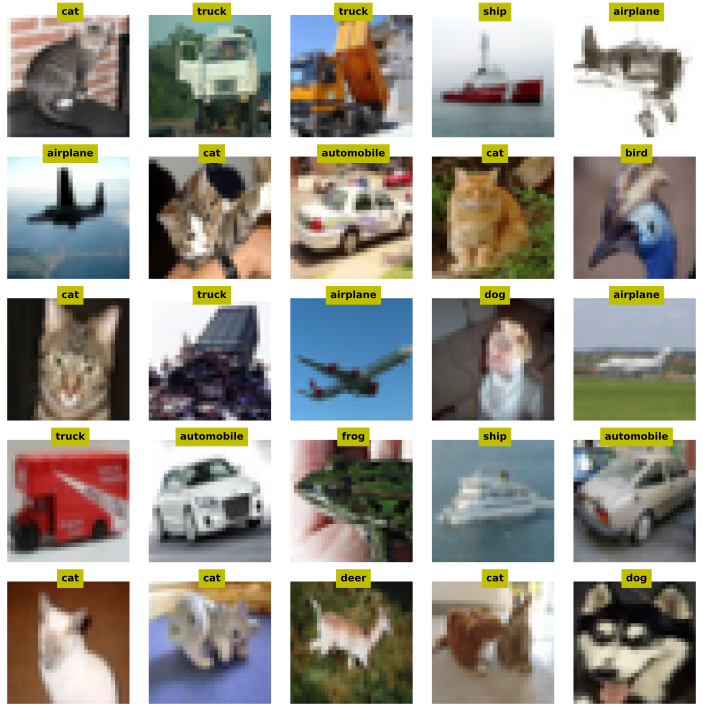

In [145]:
fig, axs = plt.subplots(5, 5, figsize = (10,10))

for ax in axs.flatten():
  img_idx = np.random.choice(len(cdata))

  img = cdata.data[img_idx,:,:,:]
  label = cdata.classes[cdata.targets[img_idx]]

  ax.imshow(img)
  ax.text(16, 0,
          label,
          ha = 'center',
          va = 'bottom',
          fontweight = 'bold',
          color = 'k',
          backgroundcolor = 'y')
  ax.axis('off')

plt.tight_layout()
plt.show()

## Transforms

In [146]:
Ts = T.Compose([
    T.ToTensor(),
    T.Resize(32*4),
    T.Grayscale(num_output_channels = 1)
])

Ts

Compose(
    ToTensor()
    Resize(size=128, interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=1)
)

Option 1 - we can apply Ts() directly on data.

In [147]:
Ts(cdata.data[111,:,:,:])
img1 = cdata.data[111,:,:,:]
img1 = Ts(cdata.data[111,:,:,:])
img1.shape

torch.Size([1, 128, 128])

Option 2 - we can use .transform method

In [148]:
cdata.transform = Ts
img2 = cdata.transform(cdata.data[222,:,:,:])
img2.shape

torch.Size([1, 128, 128])

Option 3 - we can transform directly in data upload

In [149]:
cdata = torchvision.datasets.CIFAR10(root = 'cifar10', download = True, transform = Ts)
img3 = cdata.transform(cdata.data[333,:,:,:])
img3.shape

torch.Size([1, 128, 128])

## Plot

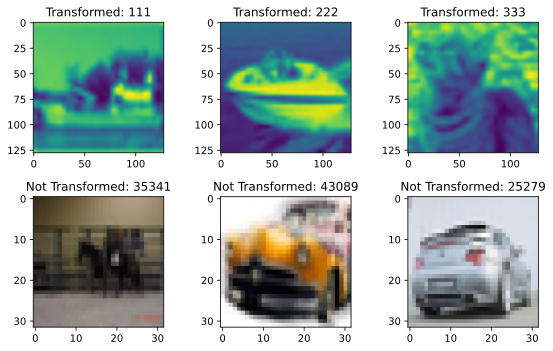

In [150]:
fig, axs = plt.subplots(2,3,figsize = (8,5))

imgs = [img1, img2, img3]
ids = ['111', '222', '333']

for i, ax in enumerate(axs.flatten()):
  if i < 3:
    ax.imshow(imgs[i].squeeze())
    ax.set_title(f'Transformed: {ids[i]}')
  else:
    img_idx = np.random.choice(cdata.data.shape[0])
    img = cdata.data[img_idx]
    ax.imshow(img.squeeze())
    ax.set_title(f'Not Transformed: {img_idx}')

plt.tight_layout()
plt.show()

# Creating and Using DataLoaders

* Why and when we need to create custom DataSets
* How to make own custom DataSet class
* More about how image transformations are applied during learning

1. Import the data (handled with torchvision)
2. Create a custom DataSet class (handled with torchvision)
3. Define the transformations
4. Create a DataSet with your data and transformation
5. Create a DataLoader (same as usual)

In [142]:
import numpy as np
import torch

import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipython-input-2067744494.py:10: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


## Import Data

In [143]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv'), delimiter = ',')

labels = data[:8,0]
data = data[:8,1:]

data = data / np.max(data)

dataT = torch.Tensor(data).float()
labelsT = torch.tensor(labels).long()

dataT.shape, labelsT.shape

(torch.Size([8, 784]), torch.Size([8]))

We need to create 2D from 1D.

In [144]:
dataT = dataT.reshape(dataT.shape[0], 28, 28)
dataT.shape

torch.Size([8, 28, 28])

Let's check the data

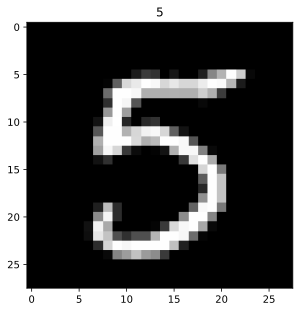

In [145]:
rand_row = np.random.choice(dataT.shape[0])

plt.imshow(dataT[rand_row].squeeze(), cmap = 'grey')
plt.title(labelsT[rand_row].item())
plt.show()

## Custom Dataset

Let's call helper for TensorDataset

In [146]:
# ??torch.utils.data.TensorDataset

After copying class TensorDataset let's modify it a bit

In [147]:
class CustomDataset():
  def __init__(self, tensors, transforms = None):
      assert len(tensors) == 2, (
          "Expected tensors: (data, labels)"
      )
      assert (tensors[0].size(0) == tensors[1].size(0)), (
          "Size mismatch between tensors"
      )
      self.tensors = tensors
      self.transforms = transforms

  # what to do if someone wants an item
  def __getitem__(self, index):

      if self.transforms is not None:
        x = self.transforms(self.tensors[0][index])
      else:
        x = self.tensors[0][index]

      y = self.tensors[1][index]

      return x, y

  def __len__(self):
      return self.tensors[0].size(0)

## Transform

In [148]:
# Note: several transforms work only on PIL-format data, so it's common to transform to PIL,
# apply transformations, then transform back to tensor.

img_transforms = T.Compose([
    T.ToPILImage(),
    T.RandomVerticalFlip(p = .5),
    T.ToTensor()
])

img_transforms

Compose(
    ToPILImage()
    RandomVerticalFlip(p=0.5)
    ToTensor()
)

## Dataset to DataLoader

In [149]:
train_data = CustomDataset((dataT, labelsT), transforms = img_transforms)

data_loader = DataLoader(train_data, batch_size = 8 ,shuffle = False)

In [150]:
type(train_data)

__main__.CustomDataset

## Output

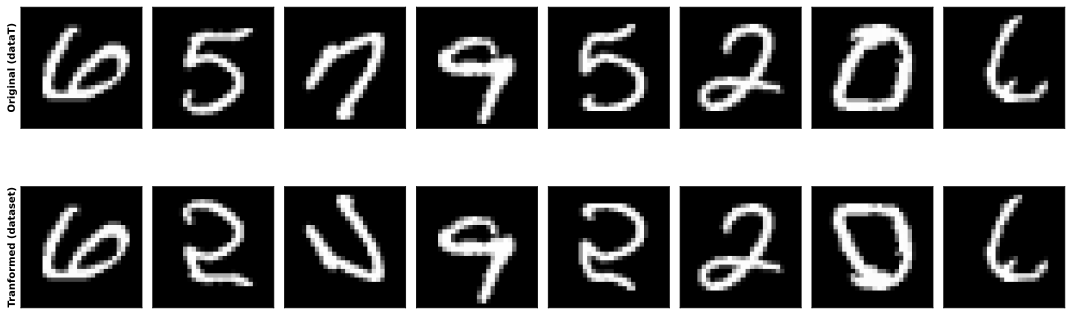

In [151]:
X, y = next(iter(data_loader))

fig, axs = plt.subplots(2,8,figsize=(15,6))

for i in range(8):
  axs[0][i].imshow(dataT[i], cmap = 'grey')
  axs[1][i].imshow(X[i].squeeze(), cmap = 'grey')

  for row in range(2):
    axs[row][i].set_xticks([])
    axs[row][i].set_yticks([])

axs[0,0].set_ylabel('Original (dataT)', fontweight = 'bold')
axs[1,0].set_ylabel('Tranformed (dataset)', fontweight = 'bold')

plt.tight_layout()
plt.show()

We can see that (roughly) half of images are flipped vertically, i.e. exactly what we've defined in transform (p = .5)

It's worthy to note that our train_data wasn't extended.

In [152]:
len(train_data)

8